### It is recommended to use GPU T4$\times$2 to run the code.

In [1]:
import sys
print("Python:", sys.version)

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.9 MB/s eta 0:00:00


In [3]:
import os
import pickle as pkl
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import tqdm

from torch_geometric.data import HeteroData

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__)
print('torch cuda:', torch.version.cuda)
print('cuda available:', torch.cuda.is_available())
print('device:', device)

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

torch: 2.10.0+cpu
torch cuda: None
cuda available: False
device: cpu


In [4]:

import os
import pickle as pkl
import numpy as np


def read_txt(file):
    res_list = []
    with open(file, "r") as f:
        for line in f:
            res_list.append(list(map(int, line.strip().split())))
    return res_list

base_path = "/kaggle/input/competitions/cs-3319-02-project-2-recommendation-systems-2026-spring"

cite_file = "paper_file_ann.txt"
train_ref_file = "bipartite_train_ann.txt"
test_ref_file = "bipartite_test_ann.txt"
coauthor_file = "author_file_ann.txt"
feature_file = "feature.pkl"

citation = read_txt(os.path.join(base_path, cite_file))
existing_refs = read_txt(os.path.join(base_path, train_ref_file))
refs_to_pred = read_txt(os.path.join(base_path, test_ref_file))
coauthor = read_txt(os.path.join(base_path, coauthor_file))

with open(os.path.join(base_path, feature_file), 'rb') as f:
    paper_feature = pkl.load(f)

print("base_path:", base_path)
print(f"Number of citation edges: {len(citation)}")
print(f"Number of existing references: {len(existing_refs)}")
print(f"Number of author-paper pairs to predict: {len(refs_to_pred)}")
print(f"Number of coauthor edges: {len(coauthor)}")
print(f"Shape of paper features: {paper_feature.shape}")


base_path: /kaggle/input/competitions/cs-3319-02-project-2-recommendation-systems-2026-spring
Number of citation edges: 327113
Number of existing references: 682421
Number of author-paper pairs to predict: 2047262
Number of coauthor edges: 9663
Shape of paper features: torch.Size([79937, 512])


In [5]:
import pandas as pd

cite_edges = pd.DataFrame(citation, columns=['source', 'target'])
cite_edges = cite_edges.set_index(
    "c-" + cite_edges.index.astype(str)
)

ref_edges = pd.DataFrame(existing_refs, columns=['source', 'target'])
ref_edges = ref_edges.set_index(
    "r-" + ref_edges.index.astype(str)
)

coauthor_edges = pd.DataFrame(coauthor, columns=['source', 'target'])
coauthor_edges = coauthor_edges.set_index(
    "a-" + coauthor_edges.index.astype(str)
)

cite_edges.head()

,source,target
c-0,19068,75036
c-1,19068,37541
c-2,19068,31713
c-3,19068,19619
c-4,19068,19582


In [6]:
node_tmp = pd.concat([cite_edges.loc[:, 'source'], cite_edges.loc[:, 'target'], ref_edges.loc[:, 'target']])
node_papers = pd.DataFrame(index=pd.unique(node_tmp))

node_tmp = pd.concat([ref_edges['source'], coauthor_edges['source'], coauthor_edges['target']])
node_authors = pd.DataFrame(index=pd.unique(node_tmp))

print("Number of paper nodes: {}, number of author nodes: {}".format(len(node_papers), len(node_authors)))

Number of paper nodes: 79937, number of author nodes: 6611


In [7]:
# Build train/test edges.

train_refs = ref_edges.sample(frac=0.9, random_state=0, axis=0)
test_true_refs = ref_edges[~ref_edges.index.isin(train_refs.index)].copy()
test_true_refs.loc[:, 'label'] = 1

existing_ref_set = set(map(tuple, ref_edges[['source', 'target']].to_numpy().tolist()))
num_test_pos = len(test_true_refs)
author_ids = node_authors.index.to_numpy(dtype=np.int64)
paper_ids = node_papers.index.to_numpy(dtype=np.int64)

neg_pairs = []
rng = np.random.default_rng(0)
while len(neg_pairs) < num_test_pos:
    src = int(rng.choice(author_ids))
    dst = int(rng.choice(paper_ids))
    if (src, dst) not in existing_ref_set:
        neg_pairs.append((src, dst))

test_false_refs = pd.DataFrame(neg_pairs, columns=['source', 'target'])
test_false_refs.loc[:, 'label'] = 0

test_refs = pd.concat([test_true_refs, test_false_refs], ignore_index=True)
test_refs = test_refs.sample(frac=1, random_state=0, axis=0).reset_index(drop=True)
test_refs.head()


,source,target,label
0,2174,21324,0
1,6517,35189,0
2,3283,5129,1
3,2308,36164,1
4,3275,70526,1


In [8]:
train_ref_tensor = torch.as_tensor(train_refs[['source', 'target']].to_numpy(), dtype=torch.long)
cite_tensor = torch.as_tensor(cite_edges[['source', 'target']].to_numpy(), dtype=torch.long)
coauthor_tensor = torch.as_tensor(coauthor_edges[['source', 'target']].to_numpy(), dtype=torch.long)

test_ref_arr = np.array(refs_to_pred, dtype=np.int64) if len(refs_to_pred) > 0 else np.zeros((0, 2), dtype=np.int64)
num_authors = int(max(
    ref_edges['source'].max(),
    coauthor_edges['source'].max(),
    coauthor_edges['target'].max(),
    test_ref_arr[:, 0].max() if len(test_ref_arr) else 0,
) + 1)
num_papers = int(max(
    cite_edges['source'].max(),
    cite_edges['target'].max(),
    ref_edges['target'].max(),
    test_ref_arr[:, 1].max() if len(test_ref_arr) else 0,
    paper_feature.shape[0] - 1,
) + 1)

paper_x = torch.as_tensor(paper_feature, dtype=torch.float)
if paper_x.size(0) < num_papers:
    pad = torch.zeros(num_papers - paper_x.size(0), paper_x.size(1), dtype=paper_x.dtype)
    paper_x = torch.cat([paper_x, pad], dim=0)
elif paper_x.size(0) > num_papers:
    paper_x = paper_x[:num_papers]

data = HeteroData()
data['author'].num_nodes = num_authors
data['paper'].x = paper_x
data['paper'].num_nodes = num_papers

# author -> paper reference edges
data['author', 'ref', 'paper'].edge_index = train_ref_tensor.t().contiguous()
# reverse relation for message passing from paper back to author
data['paper', 'beref', 'author'].edge_index = train_ref_tensor[:, [1, 0]].t().contiguous()

# citation and coauthor edges are treated as undirected by adding reverse edges,
# matching the original DGL code.
data['paper', 'cite', 'paper'].edge_index = torch.cat([
    cite_tensor,
    cite_tensor[:, [1, 0]],
], dim=0).t().contiguous()
data['author', 'coauthor', 'author'].edge_index = torch.cat([
    coauthor_tensor,
    coauthor_tensor[:, [1, 0]],
], dim=0).t().contiguous()

data = data.to(device)
print(data)
print('metadata:', data.metadata())


HeteroData(
  author={ num_nodes=6611 },
  paper={
    x=[79937, 512],
    num_nodes=79937,
  },
  (author, ref, paper)={ edge_index=[2, 614179] },
  (paper, beref, author)={ edge_index=[2, 614179] },
  (paper, cite, paper)={ edge_index=[2, 654226] },
  (author, coauthor, author)={ edge_index=[2, 19326] }
)
metadata: (['author', 'paper'], [('author', 'ref', 'paper'), ('paper', 'beref', 'author'), ('paper', 'cite', 'paper'), ('author', 'coauthor', 'author')])


In [9]:
class HeteroMeanConv(nn.Module):
    """A lightweight hetero mean-aggregation layer implemented with pure PyTorch.

    The layer consumes PyG's HeteroData / edge_index_dict format but avoids compiled
    PyG extensions. For efficiency, it first averages source node features at each
    destination node and then applies relation-specific linear projections.
    """
    def __init__(self, metadata, in_dims, out_dim):
        super().__init__()
        node_types, edge_types = metadata
        self.node_types = list(node_types)
        self.edge_types = list(edge_types)
        self.rel_lins = nn.ModuleDict({
            self._key(edge_type): nn.Linear(in_dims[edge_type[0]], out_dim, bias=False)
            for edge_type in self.edge_types
        })
        self.self_lins = nn.ModuleDict({
            node_type: nn.Linear(in_dims[node_type], out_dim)
            for node_type in self.node_types
        })

    @staticmethod
    def _key(edge_type):
        return '__'.join(edge_type)

    def reset_parameters(self):
        for layer in self.rel_lins.values():
            layer.reset_parameters()
        for layer in self.self_lins.values():
            layer.reset_parameters()

    def forward(self, x_dict, edge_index_dict, num_nodes_dict):
        out_dict = {
            node_type: self.self_lins[node_type](x_dict[node_type])
            for node_type in self.node_types
        }
        rel_count = {node_type: 1 for node_type in self.node_types}  # self term

        for edge_type, edge_index in edge_index_dict.items():
            src_type, _, dst_type = edge_type
            src, dst = edge_index
            src_x = x_dict[src_type]
            agg = src_x.new_zeros((num_nodes_dict[dst_type], src_x.size(-1)))
            deg = src_x.new_zeros((num_nodes_dict[dst_type], 1))
            agg.index_add_(0, dst, src_x[src])
            deg.index_add_(
                0,
                dst,
                torch.ones((dst.numel(), 1), dtype=src_x.dtype, device=src_x.device),
            )
            agg = agg / deg.clamp(min=1.0)
            out_dict[dst_type] = out_dict[dst_type] + self.rel_lins[self._key(edge_type)](agg)
            rel_count[dst_type] += 1

        return {
            node_type: out_dict[node_type] / rel_count[node_type]
            for node_type in self.node_types
        }


class HeteroRecommender(nn.Module):
    def __init__(self, metadata, paper_in_dim, hidden_dim=64, out_dim=10, author_in_dim=512):
        super().__init__()
        self.author_emb = nn.Embedding(num_authors, author_in_dim)
        self.paper_lin = nn.Linear(paper_in_dim, author_in_dim)
        self.num_nodes_dict = {
            'author': num_authors,
            'paper': num_papers,
        }

        self.conv1 = HeteroMeanConv(
            metadata,
            in_dims={'author': author_in_dim, 'paper': author_in_dim},
            out_dim=hidden_dim,
        )
        self.conv2 = HeteroMeanConv(
            metadata,
            in_dims={'author': hidden_dim, 'paper': hidden_dim},
            out_dim=out_dim,
        )

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.author_emb.weight)
        self.paper_lin.reset_parameters()
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()

    def encode(self, data):
        x_dict = {
            'author': self.author_emb.weight,
            'paper': self.paper_lin(data['paper'].x),
        }
        x_dict = self.conv1(x_dict, data.edge_index_dict, self.num_nodes_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = self.conv2(x_dict, data.edge_index_dict, self.num_nodes_dict)
        return x_dict

    def decode(self, z_dict, edge_label_index):
        src, dst = edge_label_index
        return (z_dict['author'][src] * z_dict['paper'][dst]).sum(dim=-1)


def sample_negative_edges(num_samples, num_authors, num_papers, existing_edges, device):
    # Ensures sampled pairs are not known positive refs.
    neg_edges = []
    while len(neg_edges) < num_samples:
        need = num_samples - len(neg_edges)
        src = torch.randint(0, num_authors, (need * 2,), device='cpu')
        dst = torch.randint(0, num_papers, (need * 2,), device='cpu')
        for s, d in zip(src.tolist(), dst.tolist()):
            if (s, d) not in existing_edges:
                neg_edges.append((s, d))
                if len(neg_edges) == num_samples:
                    break
    return torch.tensor(neg_edges, dtype=torch.long, device=device).t().contiguous()


In [10]:
model = HeteroRecommender(
    data.metadata(),
    paper_in_dim=data['paper'].x.size(-1),
    hidden_dim=64,
    out_dim=10,
    author_in_dim=512,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)

pos_edge_index = data['author', 'ref', 'paper'].edge_index
existing_train_set = set(map(tuple, train_refs[['source', 'target']].to_numpy().tolist()))

# Each epoch performs one full-graph message-passing pass, then trains on a sampled
# set of positive/negative author-paper edges.
train_edge_batch_size = min(32768, pos_edge_index.size(1))
num_epochs = 60

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    batch_perm = torch.randperm(pos_edge_index.size(1), device=device)[:train_edge_batch_size]
    pos_batch = pos_edge_index[:, batch_perm]
    neg_batch = sample_negative_edges(
        pos_batch.size(1), num_authors, num_papers, existing_train_set, device
    )

    z_dict = model.encode(data)
    pos_score = model.decode(z_dict, pos_batch)
    neg_score = model.decode(z_dict, neg_batch)

    loss = (1.0 - pos_score + neg_score).clamp(min=0).mean()
    loss.backward()
    optimizer.step()

    print(f'Epoch {epoch:03d}, loss={loss.item():.4f}')


Epoch 000, loss=1.0000
Epoch 001, loss=0.9979
Epoch 002, loss=0.9597
Epoch 003, loss=0.7069
Epoch 004, loss=0.6645
Epoch 005, loss=0.6073
Epoch 006, loss=0.5327
Epoch 007, loss=0.5252
Epoch 008, loss=0.4976
Epoch 009, loss=0.4692
Epoch 010, loss=0.4307
Epoch 011, loss=0.4063
Epoch 012, loss=0.3746
Epoch 013, loss=0.3656
Epoch 014, loss=0.3579
Epoch 015, loss=0.3347
Epoch 016, loss=0.3324
Epoch 017, loss=0.3041
Epoch 018, loss=0.3060
Epoch 019, loss=0.2876
Epoch 020, loss=0.2792
Epoch 021, loss=0.2523
Epoch 022, loss=0.2558
Epoch 023, loss=0.2384
Epoch 024, loss=0.2350
Epoch 025, loss=0.2324
Epoch 026, loss=0.2168
Epoch 027, loss=0.2069
Epoch 028, loss=0.2081
Epoch 029, loss=0.1921
Epoch 030, loss=0.1825
Epoch 031, loss=0.1866
Epoch 032, loss=0.1871
Epoch 033, loss=0.1807
Epoch 034, loss=0.1672
Epoch 035, loss=0.1620
Epoch 036, loss=0.1565
Epoch 037, loss=0.1524
Epoch 038, loss=0.1485
Epoch 039, loss=0.1462
Epoch 040, loss=0.1449
Epoch 041, loss=0.1451
Epoch 042, loss=0.1560
Epoch 043, 

In [11]:
with torch.no_grad():
    model.eval()
    if 'z_dict' in globals():
        node_embeddings = {k: v.detach().cpu() for k, v in z_dict.items()}
    else:
        node_embeddings = model.encode(data)
        node_embeddings = {k: v.detach().cpu() for k, v in node_embeddings.items()}
    print(node_embeddings['author'].shape, node_embeddings['paper'].shape)

torch.Size([6611, 10]) torch.Size([79937, 10])


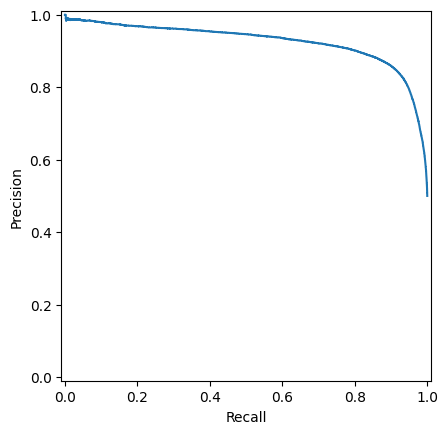

In [12]:
from numpy.linalg import norm

# Use cosine similarity to measure recommendation probability.
def cos_sim(a, b, eps=1e-12):
    return np.sum(a * b, axis=1) / (norm(a, axis=1) * norm(b, axis=1) + eps)

test_arr = test_refs[['source', 'target']].to_numpy(dtype=np.int64)
res = cos_sim(
    node_embeddings['author'][test_arr[:, 0]].numpy(),
    node_embeddings['paper'][test_arr[:, 1]].numpy(),
)

lbl_true = test_refs['label'].to_numpy().flatten()

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

precision, recall, _ = precision_recall_curve(lbl_true, np.array(res))
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.show()

In [13]:
from sklearn.metrics import f1_score

lbl_pred = np.array(res).copy()
threshold = 0.1
lbl_pred[lbl_pred >= threshold] = 1
lbl_pred[lbl_pred < threshold] = 0

print('F1-Score: {:.3f}'.format(f1_score(lbl_true, lbl_pred)))

F1-Score: 0.879


In [14]:

# Output your prediction
if 'threshold' not in globals():
    threshold = 0.5
if 'cos_sim' not in globals():
    from numpy.linalg import norm
    def cos_sim(a, b, eps=1e-12):
        return np.sum(a * b, axis=1) / (norm(a, axis=1) * norm(b, axis=1) + eps)

output_path = '/kaggle/working/Submission.csv'

test_arr = np.array(refs_to_pred, dtype=np.int64)
res = cos_sim(
    node_embeddings['author'][test_arr[:, 0]].numpy(),
    node_embeddings['paper'][test_arr[:, 1]].numpy(),
)
res[res >= threshold] = 1
res[res < threshold] = 0

data_out = []
for index, p in enumerate(list(res)):
    data_out.append([index, str(int(p))])

df = pd.DataFrame(data_out, columns=['Index', 'Predicted'], dtype=object)
df.to_csv(output_path, index=False)
print('Saved to:', output_path)
df.head()


Saved to: /kaggle/working/Submission.csv


,Index,Predicted
0,0,0
1,1,0
2,2,1
3,3,1
4,4,0
